# Diabetes Dataset


Based on the Pima Indians Hospital diabetes data , build Machine Learning binary classification model to predict if the person diabetic or Not based on below



# Features.

Pregnancies


Glucose



BloodPressure



SkinThinckness



Insulin




BMI




Diabetespedigreefunction





Age


# Label



Outcome

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
data = pd.read_csv("C:\\Users\\rache\\OneDrive\\Rachel Study Materials\\Project Dataset\\diabetes_dataset.csv")

In [3]:
# First Five rows of the dataset
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#shape of the dataset
data.shape

(768, 9)

In [5]:
# Summary of the dataset
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


* There are no null values.
* We notice there are skewness in some features.

In [6]:
# Null values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Exploratory Data Analysis


<Axes: title={'center': 'Histogram plot of the Diabetes outcome'}, xlabel='Outcome', ylabel='Count'>

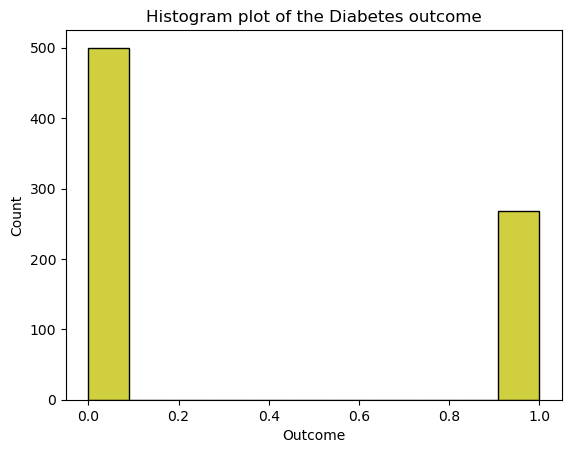

In [7]:
# Histogram
plt.title("Histogram plot of the Diabetes outcome")
sns.histplot(data['Outcome'], color = 'y')

* Around **500** people are not suffering from diabetes, about **250** are suffering from diabetes.

<Axes: title={'center': 'Swarmplot of Glucose and Insulin with Outcome'}, xlabel='Glucose', ylabel='Insulin'>

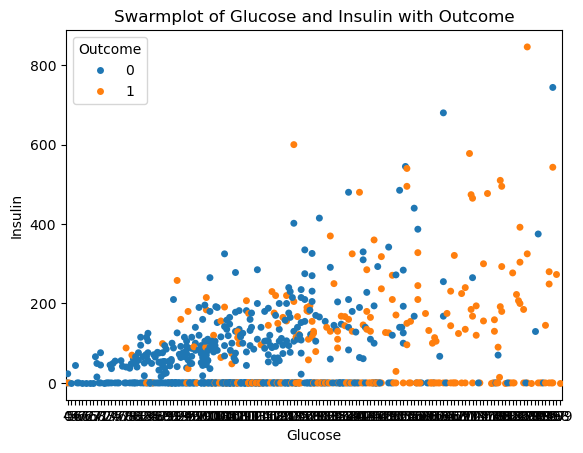

In [8]:
# Swarmplot 
plt.title("Swarmplot of Glucose and Insulin with Outcome")
sns.swarmplot(x = 'Glucose', y = 'Insulin', data = data, hue = 'Outcome')

* Here when glucose Increases Insulin also Increases in Diabetes outcome.

<Axes: title={'center': 'Scatterplot of Age and DiabetesPedigreeFunction with BMI'}, xlabel='Age', ylabel='DiabetesPedigreeFunction'>

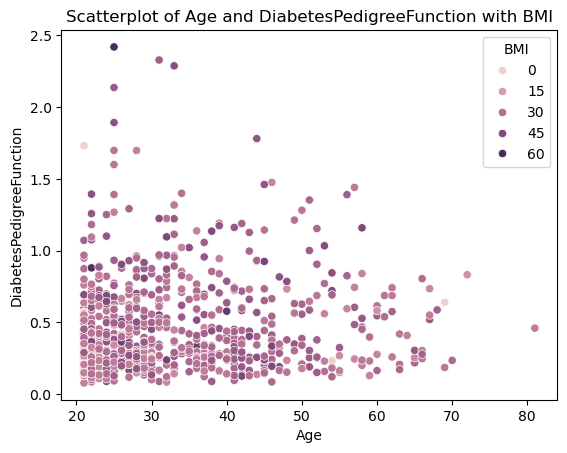

In [9]:
# Scatterplot
plt.title("Scatterplot of Age and DiabetesPedigreeFunction with BMI")
sns.scatterplot(x = 'Age', y = 'DiabetesPedigreeFunction', data = data, hue = 'BMI')

* Patients suffer from diabetes are most likely from **20 to 60** ages.
* Mostly from 20 to 40 Age their BMI around **15** and **30**.

<Axes: title={'center': 'Histogram of Bloodpressure and Skin Thickness with Pregnancies'}, xlabel='BloodPressure', ylabel='SkinThickness'>

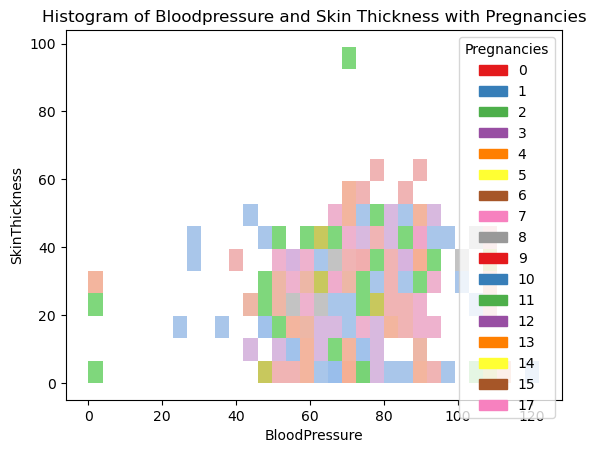

In [10]:
# Histogram
plt.title("Histogram of Bloodpressure and Skin Thickness with Pregnancies")
sns.histplot(x = 'BloodPressure', y = 'SkinThickness', data = data, hue = 'Pregnancies', palette = 'Set1')

* Patients with Blood Pressure **50 to 80** their skinthickness level from **20 to 50**.

## Data Preprocessing

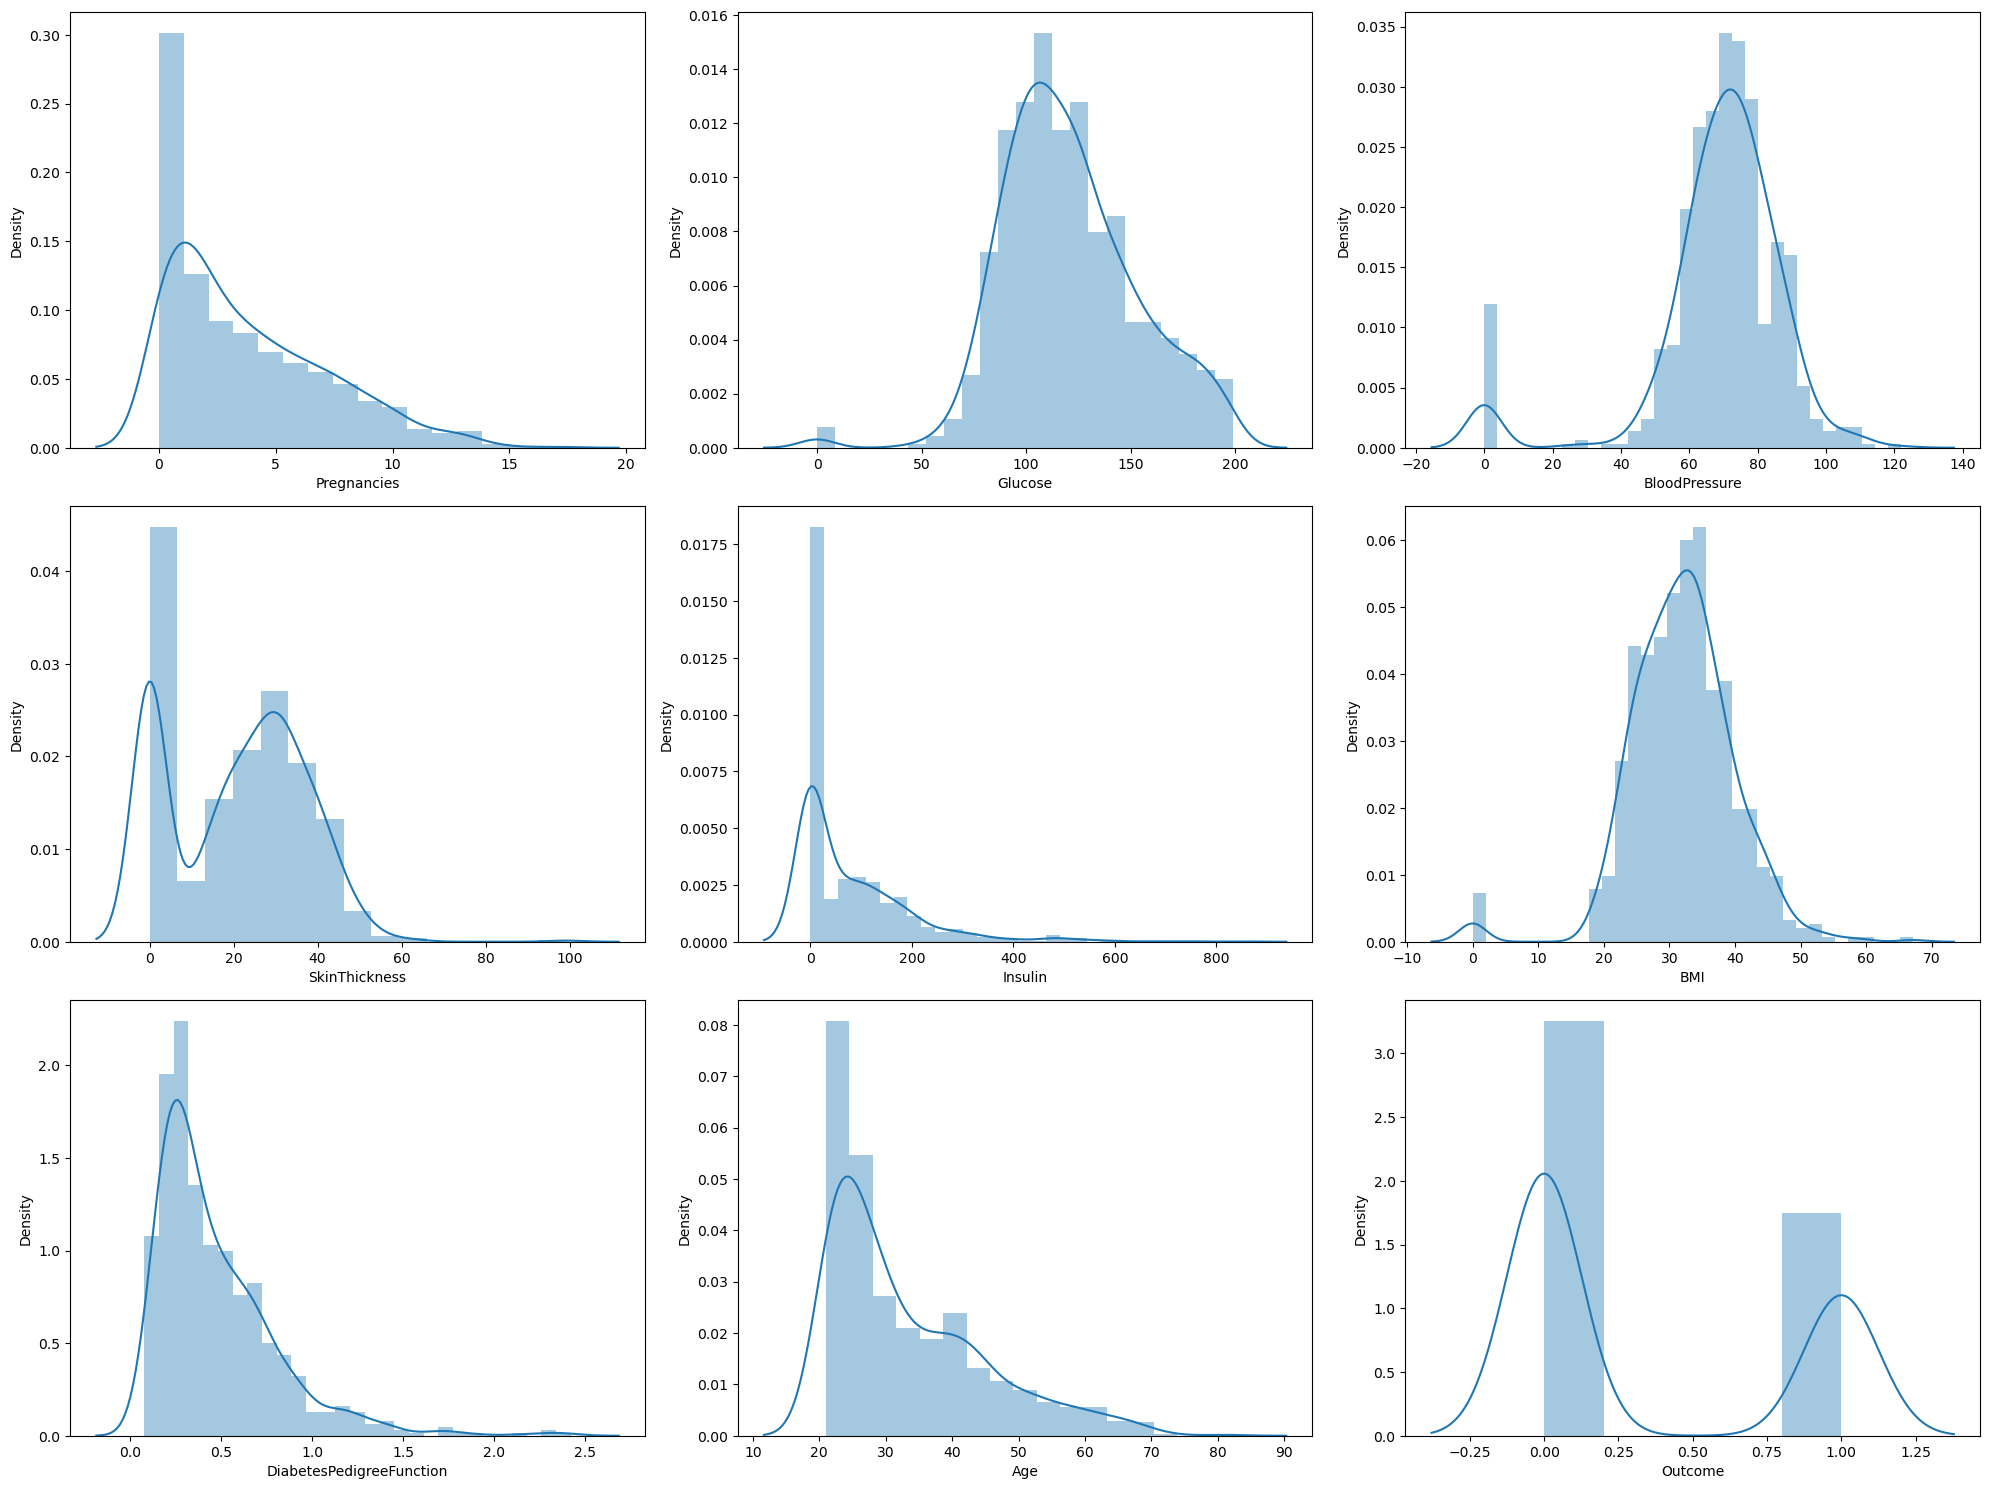

In [11]:
# check the data distribution using distplot for all the columns
plt.figure(figsize=(20,15))
graph=1
for column in data:
    if graph <=9:
        ax=plt.subplot(3,3,graph)
        sns.distplot(data[column])
        plt.xlabel(column)
    graph +=1
plt.tight_layout()

In [12]:
print(data.skew())

Pregnancies                 0.901674
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64


In [13]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

* We can see skewness in Pregnancies, BloodPressure, Insulin, DiabetesPedigreeFunction, Age.
* ***Pregnancies,Insulin, DiabetesPedigreeFunction, Age*** has **Right Skewed**
* ***Blood pressure*** is **left skewed**.
* In columns of Glucose , insulin , skin thickness , BMI and Blood Pressure the minimum value has 0, which needs to be treated by imputing with mean values.

In [14]:
#Imputing the min values of BMI, Insulin, BloodPressure, Glucose, SkinThickness replacing 0 with mean value.

data['BMI']=data['BMI'].replace(0,data['BMI'].mean())
data['Insulin']=data['Insulin'].replace(0,data['Insulin'].mean())
data['BloodPressure']=data['BloodPressure'].replace(0,data['BloodPressure'].mean())
data['Glucose']=data['Glucose'].replace(0,data['Glucose'].mean())
data['SkinThickness']=data['SkinThickness'].replace(0,data['SkinThickness'].mean())

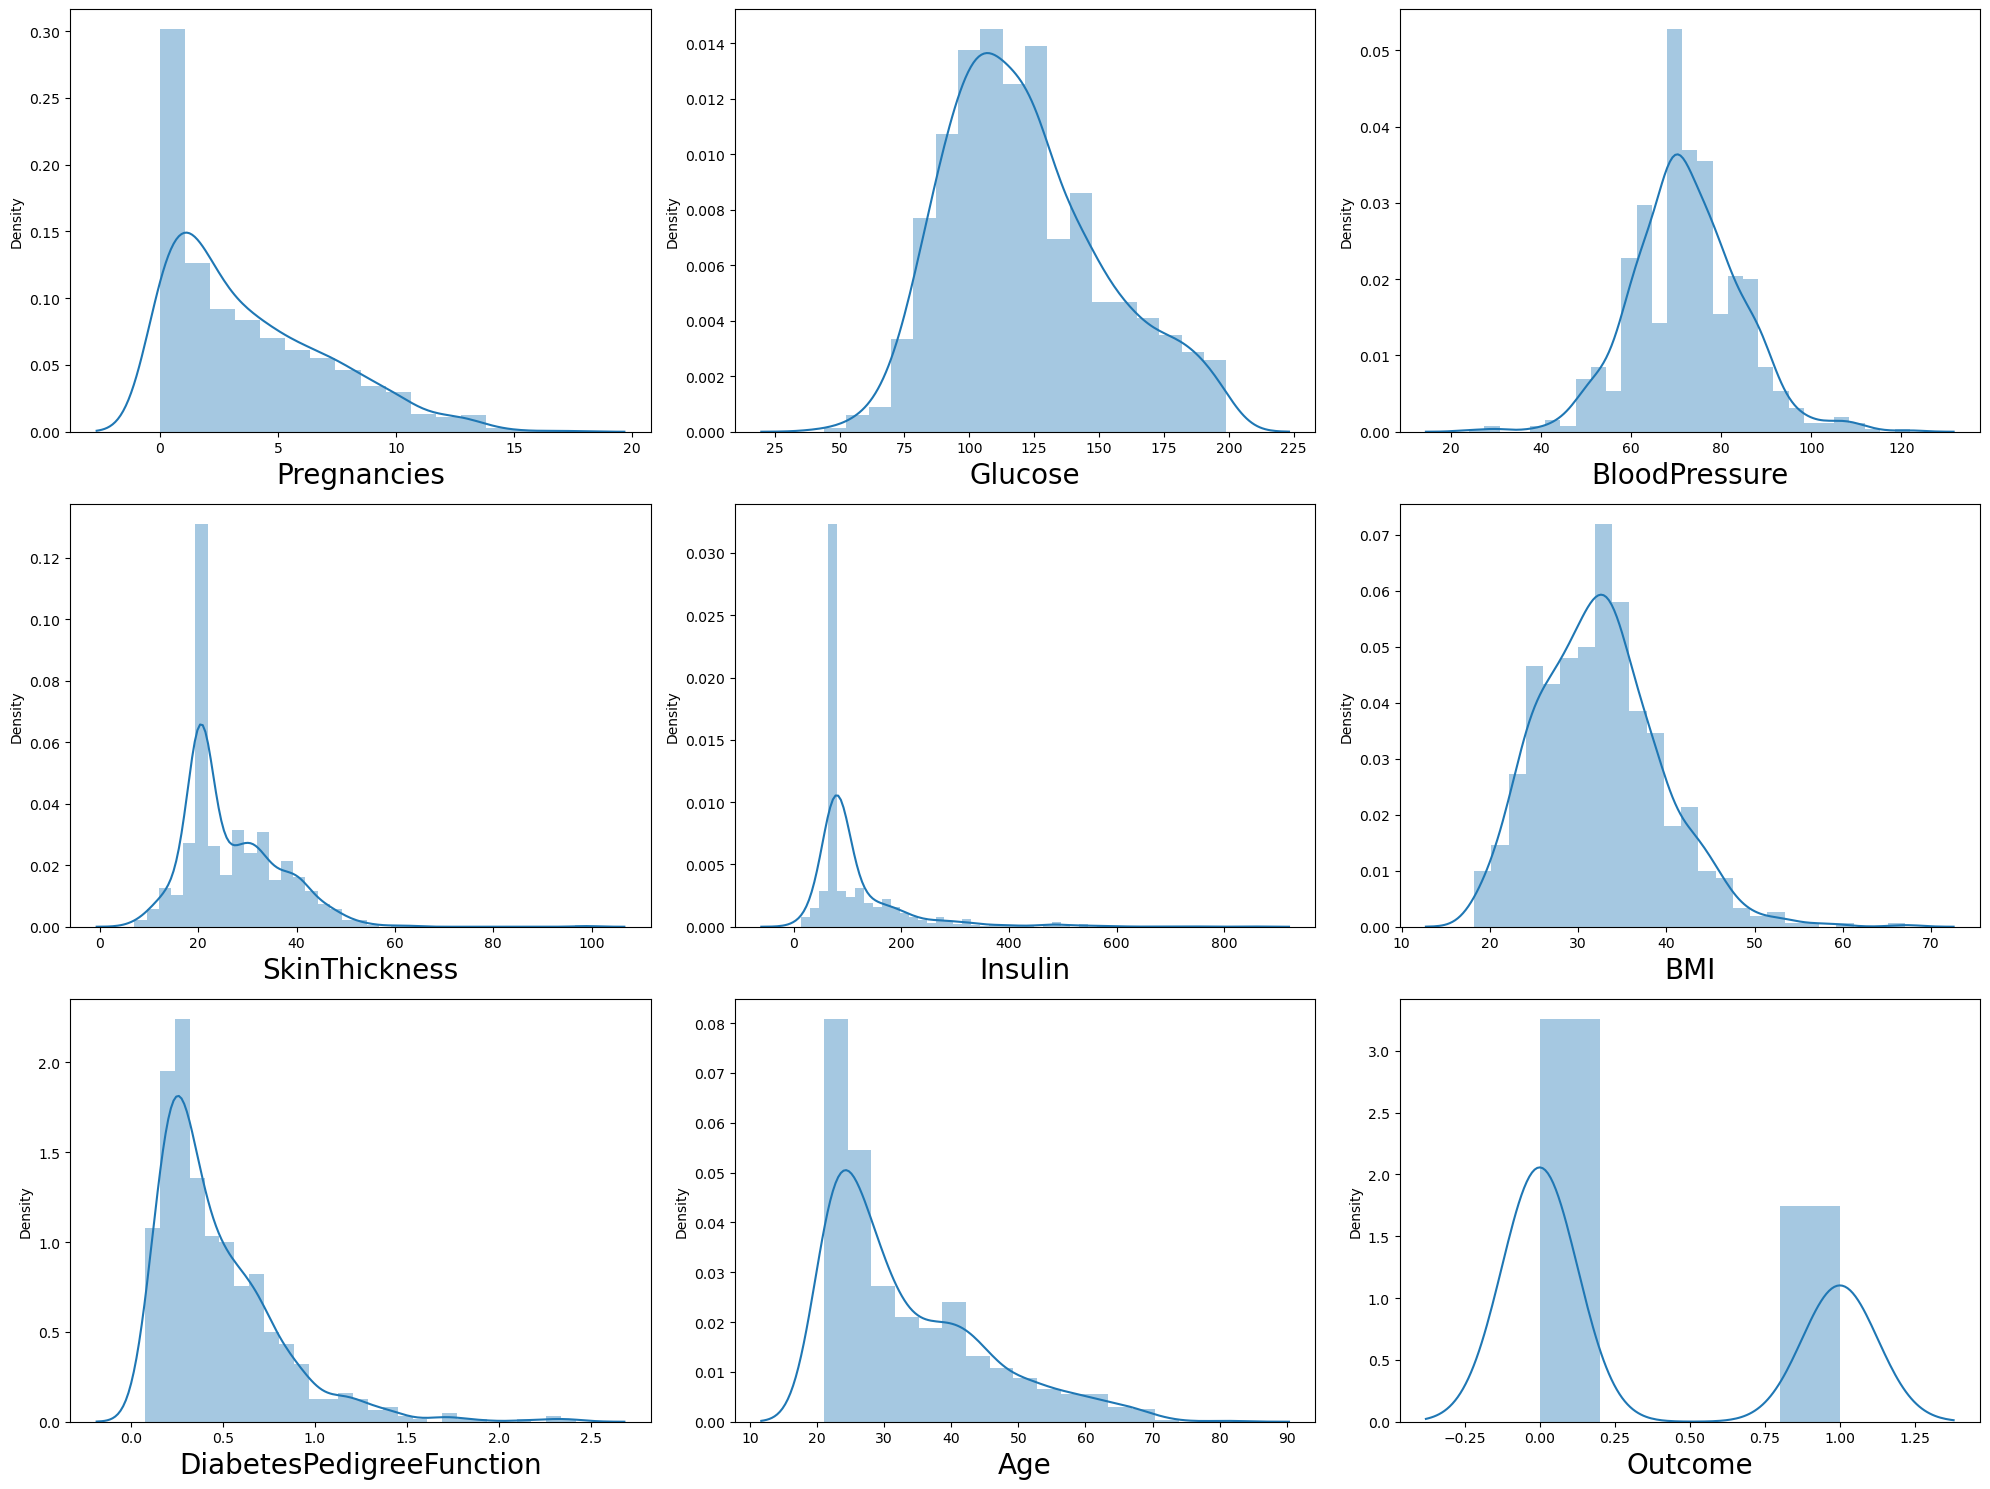

In [15]:
#Lets see how data is distributed for every column
plt.figure(figsize=(20,15))
plotnumber=1
for column in data:
    if plotnumber <=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.tight_layout()

* Minimum values have been treated but there are some outliers present in some features.

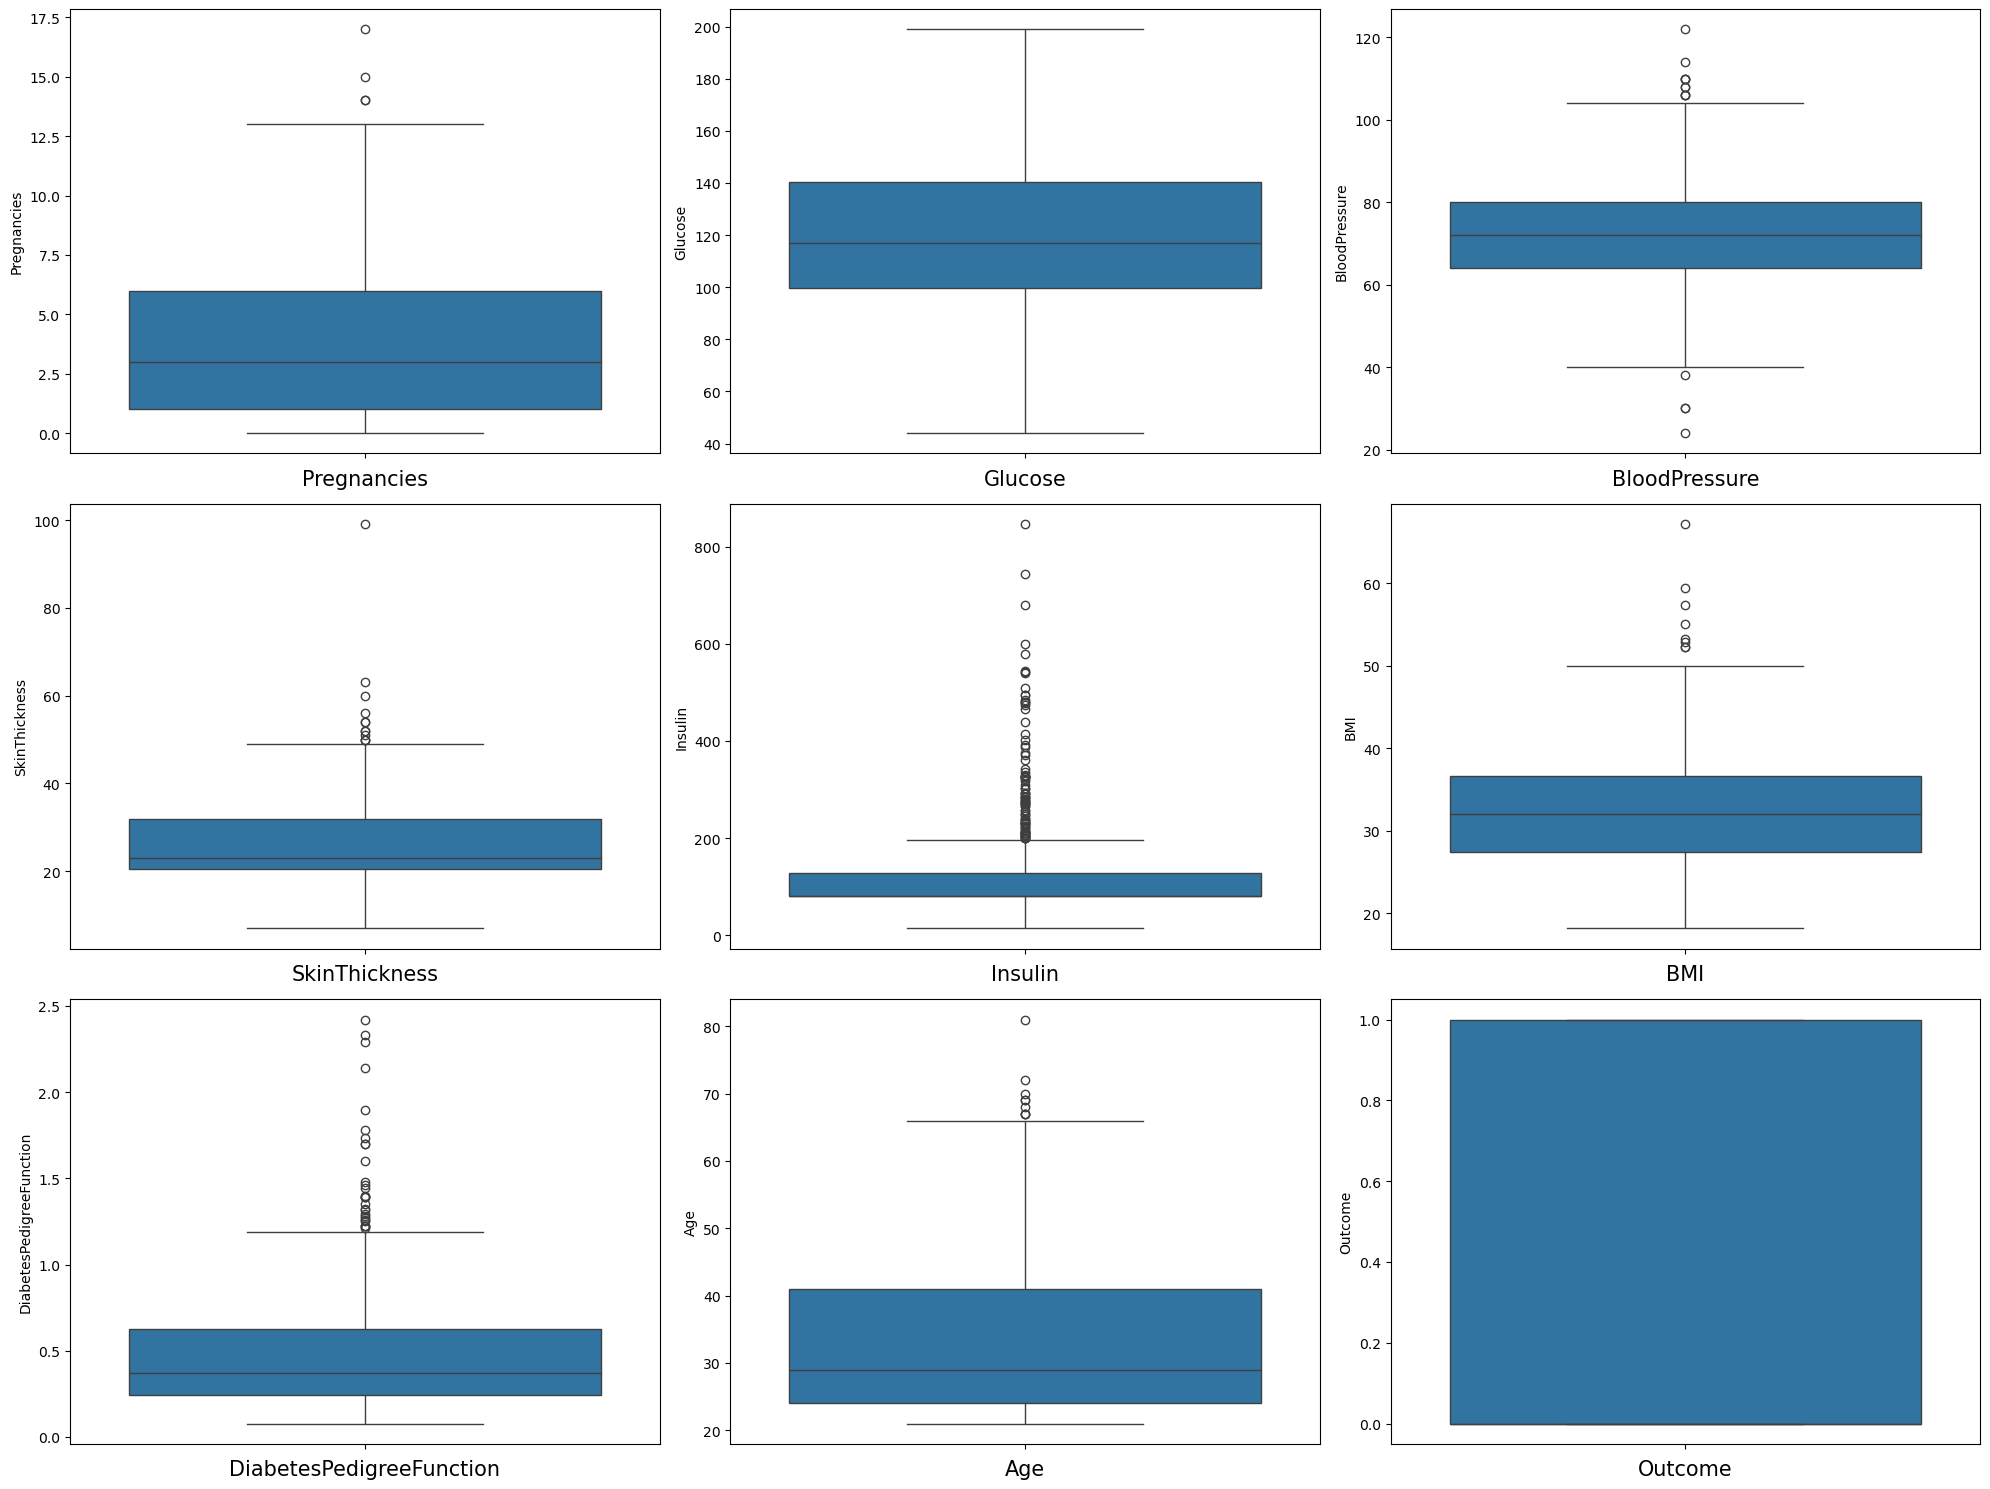

In [16]:
#Visualize the outliers using boxplot
plt.figure(figsize=(20,15))
plotnumber=1
for column in data:
    if plotnumber <=9:
        plt.subplot(3,3,plotnumber)
        ax=sns.boxplot(data[column])
        plt.xlabel(column,fontsize=15)
    plotnumber +=1
plt.tight_layout()

# **TREATING THE OUTLIERS**

* By using the Outliers detection formula we treat the outliers present in the columns Pregnancies, BloodPressure, Insulin, DiabetesPedigreeFunction, Age.

* We use Log Transformation method for skewness if it has many index values.

* We drop respective rows that shows outliers based on the formula if it less index values.

* After treating each feature outlier we reset the index to observe the shape of the data and for avoiding the loss of information on the data.


In [17]:
#Find the IQR (inter quantile range) to identify outliers

In [18]:
#1st quantile
q1=data.quantile(0.25)

In [19]:
#3rd quantile
q3=data.quantile(0.75)

In [20]:
#IQR
IQR =q3  - q1

## Outliers Detection Formula
### Higher side: Q3 +(1.5 * IQR)
### Lower Side: Q1 -(1.5 * IQR)

In [21]:
print(q1)
print(q3)
print(IQR)

Pregnancies                  1.000000
Glucose                     99.750000
BloodPressure               64.000000
SkinThickness               20.536458
Insulin                     79.799479
BMI                         27.500000
DiabetesPedigreeFunction     0.243750
Age                         24.000000
Outcome                      0.000000
Name: 0.25, dtype: float64
Pregnancies                   6.00000
Glucose                     140.25000
BloodPressure                80.00000
SkinThickness                32.00000
Insulin                     127.25000
BMI                          36.60000
DiabetesPedigreeFunction      0.62625
Age                          41.00000
Outcome                       1.00000
Name: 0.75, dtype: float64
Pregnancies                  5.000000
Glucose                     40.500000
BloodPressure               16.000000
SkinThickness               11.463542
Insulin                     47.450521
BMI                          9.100000
DiabetesPedigreeFunction     0.382

In [22]:
#Validating one Outlier
pred_high = (q3.Pregnancies + (1.5 * IQR.Pregnancies))
pred_high

np.float64(13.5)

In [23]:
#Check the indexes which have higher values
index=np.where(data['Pregnancies']>pred_high)
index

(array([ 88, 159, 298, 455]),)

In [24]:
data=data.drop(data.index[index])

In [25]:
data.reset_index()

,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
759,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
760,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
761,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
762,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [26]:
bp_low =(q1.BloodPressure - (1.5 * IQR.BloodPressure))
print(bp_low)

40.0


In [27]:
index=np.where(data['BloodPressure']<bp_low)
index

(array([ 18, 124, 593, 595]),)

In [28]:
data=data.drop(data.index[index])
print(data.shape)
data.reset_index()

(760, 9)


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
755,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
756,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
757,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
758,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [29]:
insu_high=(q3.Insulin + (1.5 * IQR.Insulin))
print(insu_high)

198.42578125


In [30]:
index=np.where(data['Insulin']>insu_high)
index

(array([  8,  13,  16,  19,  30,  38,  42,  52,  53,  55,  72,  93,  97,
        109, 129, 136, 141, 147, 150, 158, 182, 191, 195, 202, 211, 216,
        224, 227, 243, 244, 250, 254, 275, 282, 283, 292, 293, 304, 315,
        330, 354, 355, 359, 365, 370, 383, 387, 390, 404, 407, 410, 419,
        420, 447, 452, 474, 479, 480, 481, 505, 513, 532, 534, 539, 540,
        549, 555, 568, 578, 588, 598, 600, 604, 637, 647, 649, 654, 665,
        671, 677, 687, 692, 699, 702, 705, 707, 713, 740, 745]),)

In [31]:
data['Insulin'] = np.log1p(data['Insulin'])

In [32]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,4.391971,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,4.391971,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,4.391971,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,4.553877,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,5.129899,43.1,2.288,33,1


In [33]:
dpf_high=(q3.DiabetesPedigreeFunction + (1.5 *IQR.DiabetesPedigreeFunction))
print(dpf_high)

1.2


In [34]:
index=np.where(data['DiabetesPedigreeFunction']>dpf_high)
index

(array([  4,  12,  38,  44,  57,  98, 144, 183, 214, 224, 239, 241, 255,
        288, 303, 325, 365, 366, 378, 390, 440, 528, 587, 598, 610, 613,
        614, 651, 653]),)

In [35]:
data['DiabetesPedigreeFunction'] = np.log1p(data['DiabetesPedigreeFunction'])

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Density'>

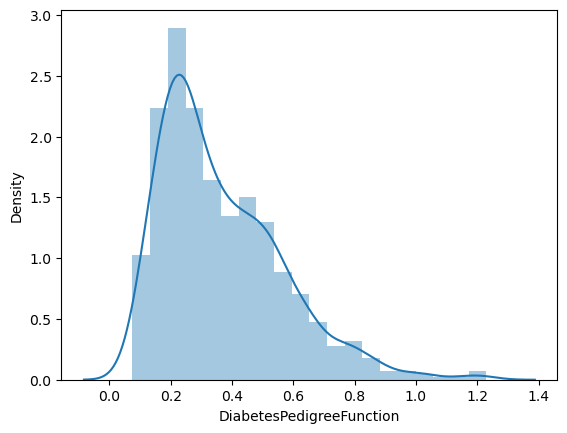

In [36]:
sns.distplot(data['DiabetesPedigreeFunction'])

In [37]:
age_high = (q3.Age + (1.5*IQR.Age))
print(age_high)

66.5


In [38]:
index=np.where(data['Age']>age_high)
index

(array([121, 358, 448, 453, 483, 531, 658, 666, 676]),)

In [39]:
data=data.drop(data.index[index])
print(data.shape)


data.reset_index()

(751, 9)


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,4.391971,33.6,0.486738,50,1
1,1,1,85.0,66.0,29.000000,4.391971,26.6,0.300845,31,0
2,2,8,183.0,64.0,20.536458,4.391971,23.3,0.514021,32,1
3,3,1,89.0,66.0,23.000000,4.553877,28.1,0.154436,21,0
4,4,0,137.0,40.0,35.000000,5.129899,43.1,1.190279,33,1
...,...,...,...,...,...,...,...,...,...,...
746,763,10,101.0,76.0,48.000000,5.198497,32.9,0.157858,63,0
747,764,2,122.0,70.0,27.000000,4.391971,36.8,0.292670,27,0
748,765,5,121.0,72.0,23.000000,4.727388,26.2,0.219136,30,0
749,766,1,126.0,60.0,20.536458,4.391971,30.1,0.299364,47,1


<Axes: xlabel='Age', ylabel='Density'>

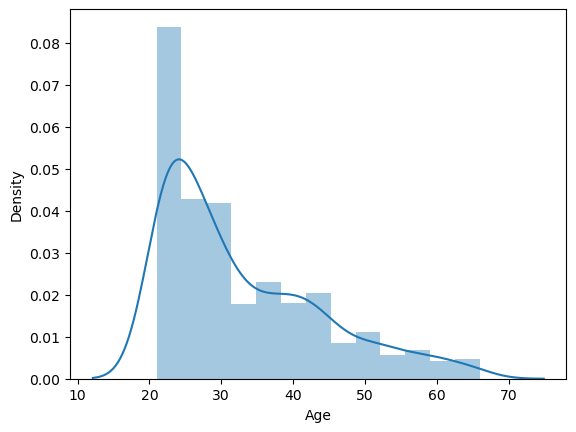

In [40]:
sns.distplot(data['Age'])

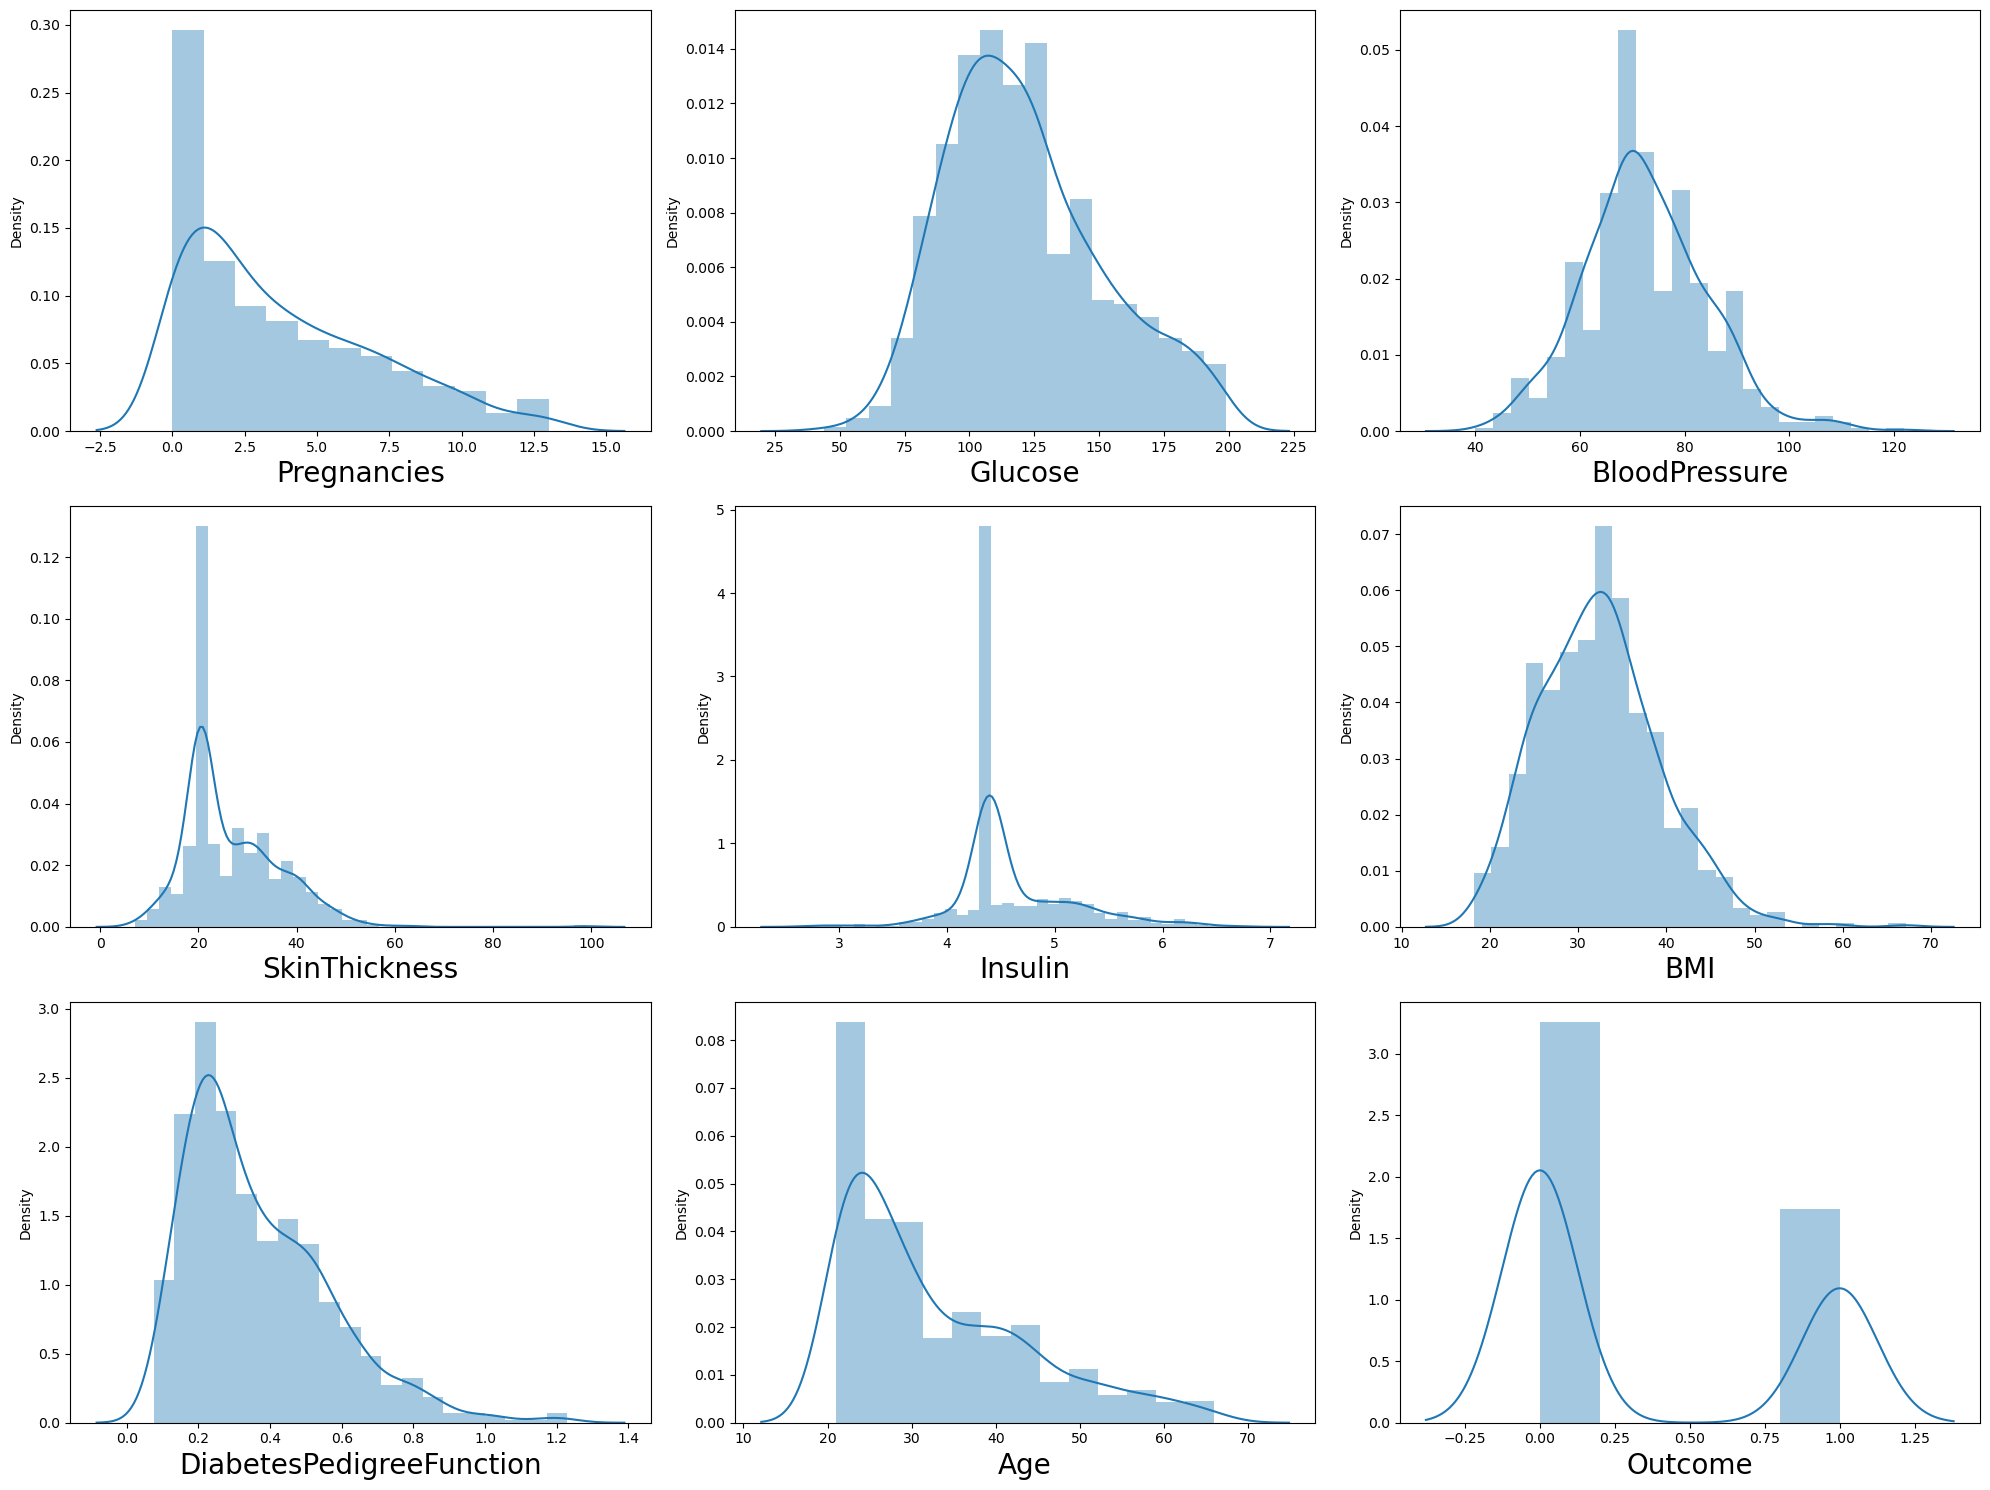

In [41]:
plt.figure(figsize=(20,15))
plotnumber = 1
for column in data :
    if plotnumber <=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.tight_layout()

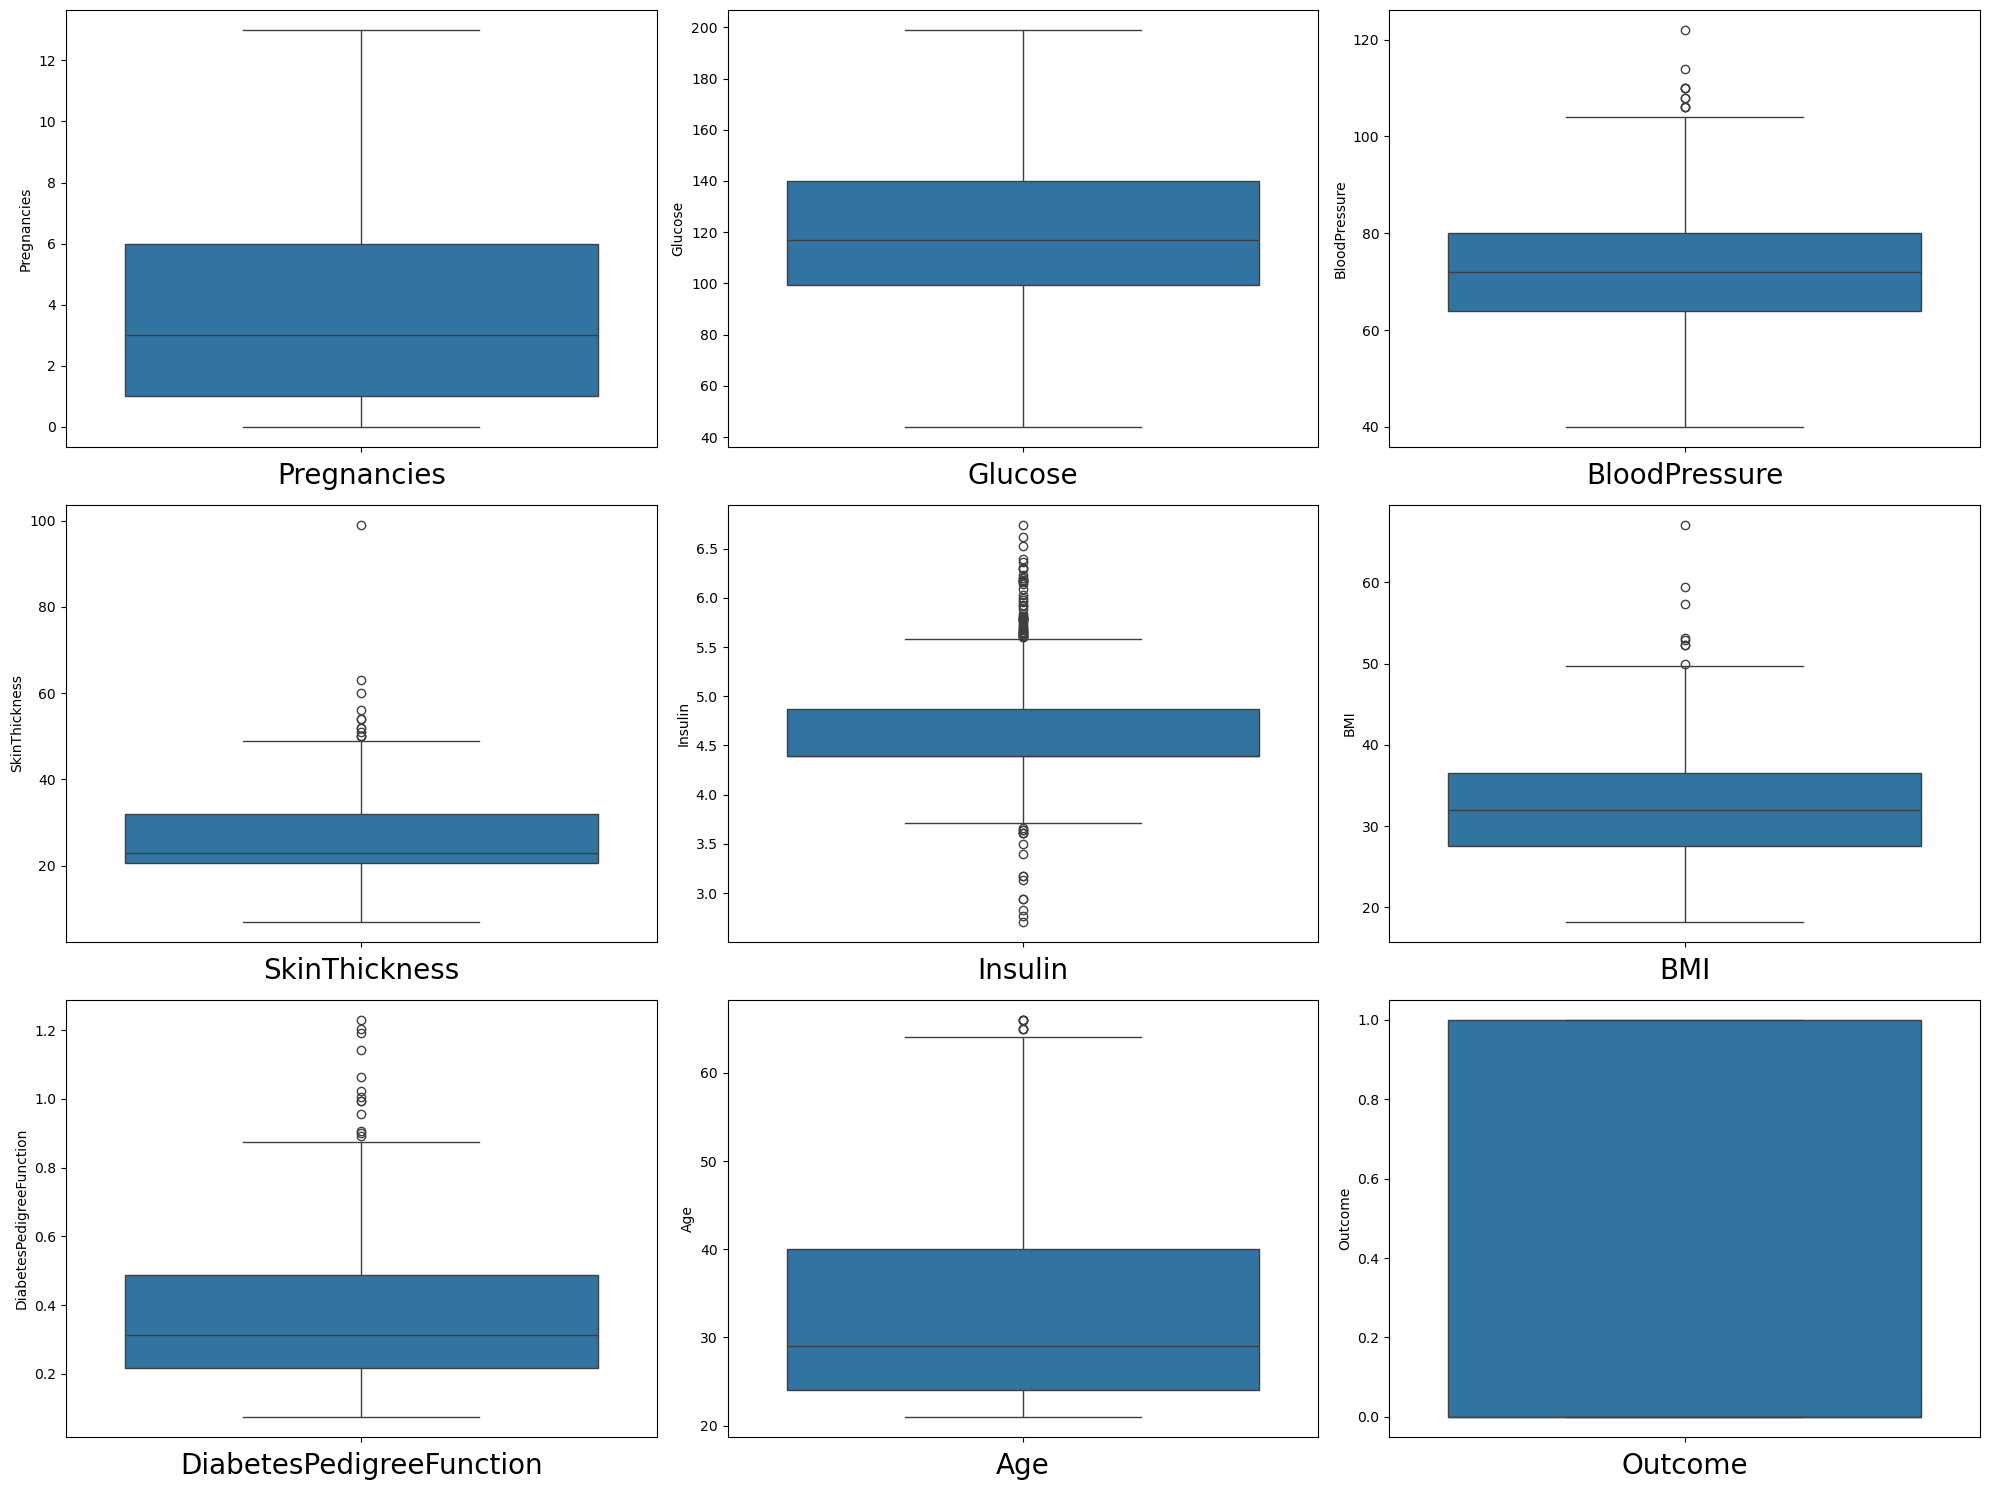

In [42]:
plt.figure(figsize=(20,15))
plotnumber = 1
for column in data :
    if plotnumber <=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.boxplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.tight_layout()

* From the dist plot and boxplot Visualization clearly shows how well the skewness and outliers are treated.
* We drop higher value indexes of Pregnancies, Blood pressure, Age since it has less index values.
* Insulin and DiabetesPedigreeFunction, we used Log Transformation Method to treat skewness and outliers. 

## Multicollinearity Problem

In [43]:
data_corr = data.corr()

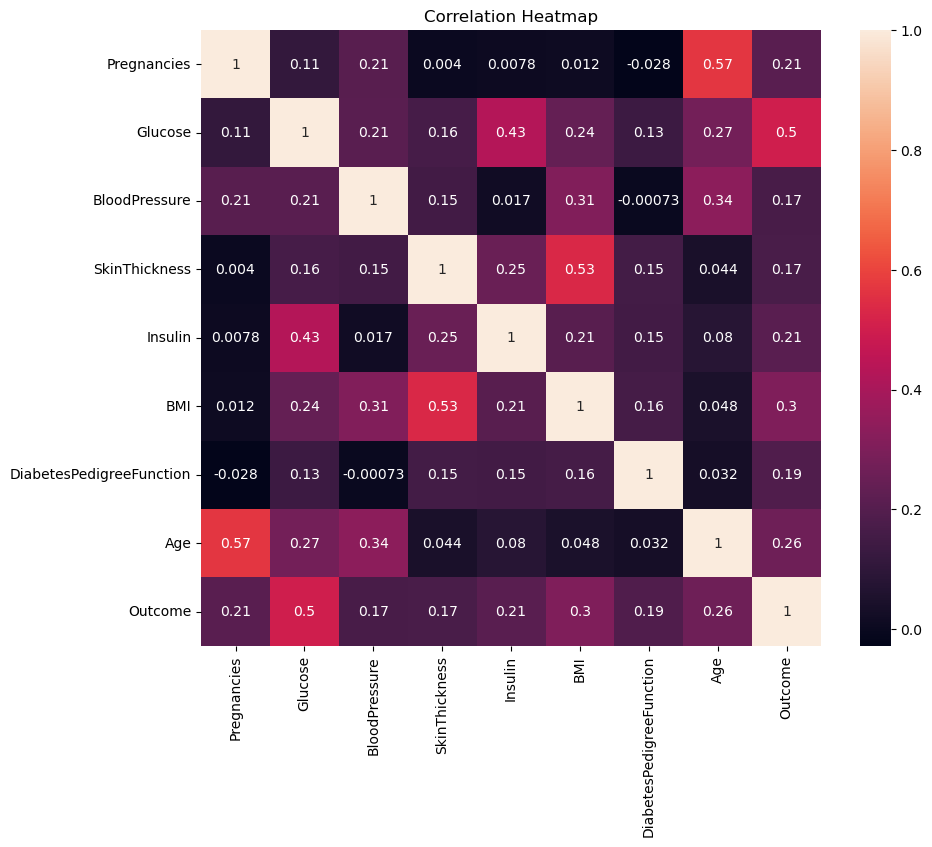

In [44]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data_corr,
    annot=True,
)

plt.title("Correlation Heatmap")
plt.show()

* In this correlation matrix there are no independent features correlated with each other.
* The Dataset is ready for model training.

In [45]:
# Saving the dataset in csv
data.to_csv('Cleaned_Diabetes_Dataset.csv', index=False)

In [46]:
df = pd.read_csv("Cleaned_Diabetes_Dataset.csv")

In [47]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,4.391971,33.6,0.486738,50,1
1,1,85.0,66.0,29.000000,4.391971,26.6,0.300845,31,0
2,8,183.0,64.0,20.536458,4.391971,23.3,0.514021,32,1
3,1,89.0,66.0,23.000000,4.553877,28.1,0.154436,21,0
4,0,137.0,40.0,35.000000,5.129899,43.1,1.190279,33,1


In [48]:
df.shape

(751, 9)